In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt

project_root = next((parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'src').exists()), Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader
from src.models import statistical as statistical_module
importlib.reload(statistical_module)
StatisticalForecaster = statistical_module.StatisticalForecaster

## MSTL Decomposition

In [2]:
print("Loading Data...")
loader = TimeSeriesDataLoader()
df = loader.load_and_clean(project_root / 'data' / 'raw' / 'Internal Submission Hourly 2024.csv')

target_col = 'Carbon intensity gCO₂eq/kWh (direct)'
train_data = df[target_col]

print("\nRunning MSTL...")
stats_model = StatisticalForecaster()
res, trend, seasonal_24, seasonal_168, residual = stats_model.run_mstl_decomposition(train_data)


Loading Data...
Loading data from /Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/data/raw/Internal Submission Hourly 2024.csv...
Data cleaned. Total baris: 8784

Running MSTL...
Running MSTL Decomposition...



Visualizing MSTL Decomposition...


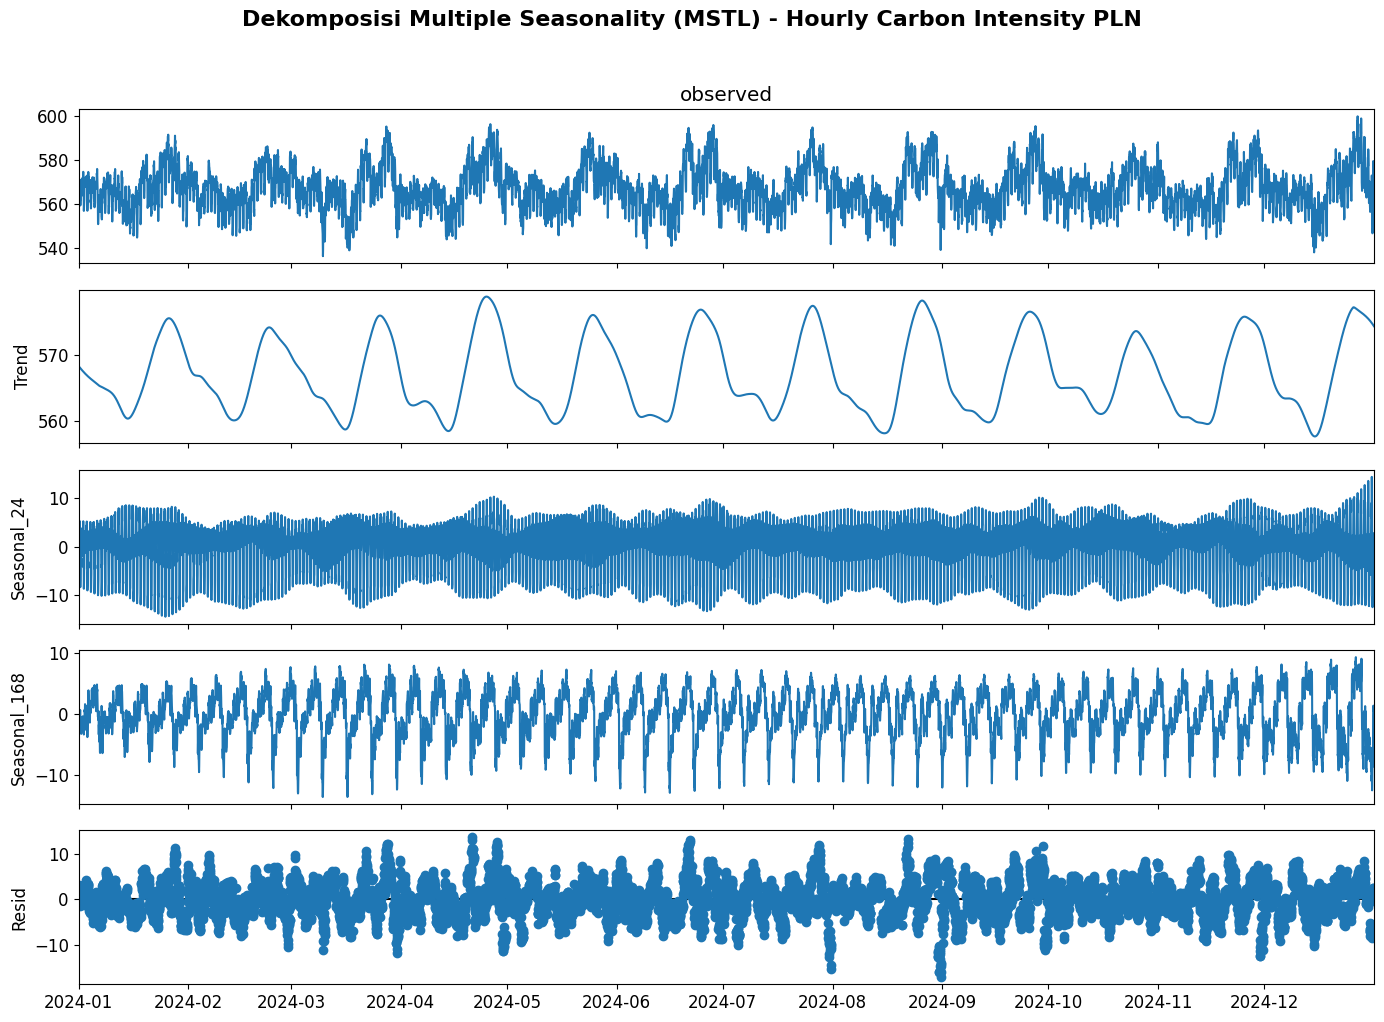

In [3]:
print("\nVisualizing MSTL Decomposition...")
plt.rc('figure', figsize=(14, 10))
plt.rc('font', size=12)

fig = res.plot()
fig.suptitle('Dekomposisi Multiple Seasonality (MSTL) - Hourly Carbon Intensity PLN', 
             fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observed:
Data Hourly Carbon Intensity PLN sepanjang 2024 berfluktuasi di kisaran 540–600 gCO₂eq/kWh, dengan volatilitas yang cukup tinggi — konsisten dengan intermittensi EBT yang jadi latar belakang penelitianmu.
#### Trend:
Komponen trend menunjukkan pola osilasi bulanan (bukan tren linear), bergerak antara ~560–580. Ini menarik — bukan tren naik/turun stabil, melainkan siklus jangka menengah yang kemungkinan mencerminkan perubahan seasonal dalam bauran energi PLN (misalnya, musim hujan → lebih banyak hidro → CI lebih rendah). Secara keseluruhan relatif stasioner dalam jangka panjang.
#### Seasonal_24 (Daily):
Amplitudo ±10–15 gCO₂eq/kWh. Pola harian sangat konsisten dan stabil sepanjang tahun. Ini adalah seasonality paling dominan secara reguler — mencerminkan variasi permintaan listrik dan kontribusi surya dalam satu hari.
#### Seasonal_168 (Weekly):
Amplitudo ±8–10 gCO₂eq/kWh, dengan struktur yang lebih kompleks dan sedikit lebih bervariasi dibanding seasonal_24. Mencerminkan perbedaan pola konsumsi antara hari kerja vs. akhir pekan.
#### Residual:
Tersebar ±10–15, dengan beberapa outlier ekstrem di sekitar Agustus–September 2024 (mendekati -15). Perlu diperiksa apakah ini event khusus (misalnya blackout, peningkatan tiba-tiba EBT). Residu yang relatif kecil dibanding sinyal mengindikasikan MSTL berhasil menangkap sebagian besar struktur.


## PROPHET DECOMPOSITION

Running Prophet Decomposition...


13:08:33 - cmdstanpy - INFO - Chain [1] start processing
13:08:35 - cmdstanpy - INFO - Chain [1] done processing


Membangun grafik dekomposisi Prophet...


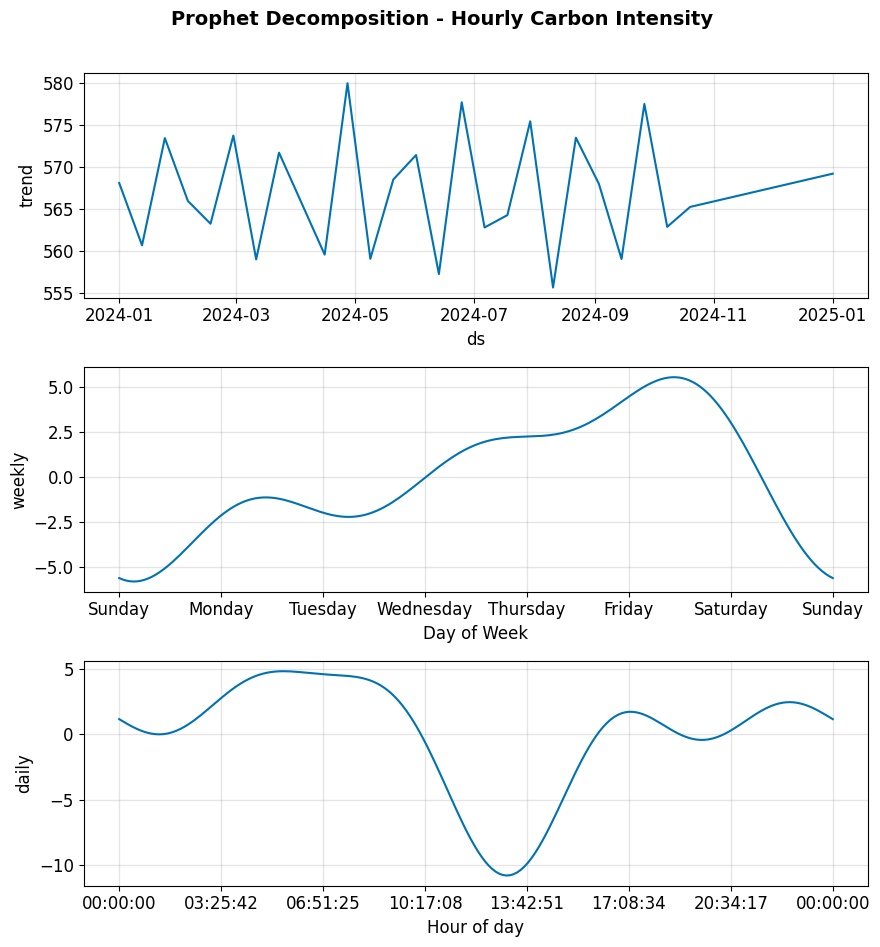

In [4]:
from prophet import Prophet
prophet_df = df.reset_index()[['Datetime (UTC)', target_col]].copy()
prophet_df.columns = ['ds', 'y']

# Run Model
prophet_model, prophet_decomp = stats_model.run_prophet_decomposition(prophet_df)

# Visualisasi
print("Membangun grafik dekomposisi Prophet...")
fig_prophet = prophet_model.plot_components(prophet_decomp, uncertainty=False)
fig_prophet.suptitle('Prophet Decomposition - Hourly Carbon Intensity', fontsize=14, y=1.05, fontweight='bold')
plt.show()

#### Trend:
Prophet menangkap trend sebagai garis yang sangat "spiky" (naik-turun tajam), bukan smooth seperti MSTL. Ini gejala overfitting trend pada changepoints - Prophet terlalu agresif mendeteksi perubahan tren, padahal itu mungkin bagian dari seasonality jangka menengah. Ini justru menunjukkan mengapa MSTL lebih superior dalam mengisolasi trend untuk data ini.


#### Weekly Seasonality:
- Minggu paling rendah (~-5.5): Aktivitas industri rendah → permintaan turun → proporsi RE lebih tinggi → CI turun
- Jumat–Sabtu tertinggi (~+5.5): Puncak aktivitas ekonomi → beban baseload fosil naik
- Ini konsisten dengan hipotesis penelitian tentang pengaruh pola konsumsi terhadap CI

#### Daily Seasonality:

- Puncak pagi ~06:00–07:00 (+5): Demand morning ramp-up
- lembah siang ~13:00 (-10): Sangat dalam. "kemungkinan" kontribusi solar PV pada jam siang menekan CI
- Recovery sore 17:00+: Solar turun, pembangkit fosil kembali mendominasi
- Pola ini adalah bukti kuat pengaruh solar intermittency terhadap CI harian

## AR, MA, & SARIMAX + FOURIER

In [5]:
# Ambil subset 1 bulan pertama (720 baris) untuk testing cepet
train_subset = train_data.iloc[:720]

# AutoRegressive (AR)
print("Training AR(24)... (Melihat 24 jam ke belakang)")
ar_results = stats_model.run_ar_model(train_subset, p=24)
print(f"AR Selesai! AIC Score: {ar_results.aic:.2f}")

# Moving Average (MA)
print("\nTraining MA(24)... (Melihat error 24 jam ke belakang)")
ma_results = stats_model.run_ma_model(train_subset, q=24)
print(f"MA Selesai! AIC Score: {ma_results.aic:.2f}")

# SARIMAX + Fourier
print("\nTraining SARIMAX + Fourier (Daily & Weekly Seasonality)...")
sarimax_results, dp_fourier = stats_model.run_sarimax_fourier(train_subset)
print(f"SARIMAX Selesai! AIC Score: {sarimax_results.aic:.2f}")

print(sarimax_results.summary())

Training AR(24)... (Melihat 24 jam ke belakang)
Running AR(24) model...
AR Selesai! AIC Score: 3593.90

Training MA(24)... (Melihat error 24 jam ke belakang)
Running MA(24) model...


/Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/justdann/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MA Selesai! AIC Score: 3583.45

Training SARIMAX + Fourier (Daily & Weekly Seasonality)...
Running SARIMAX with Fourier features...
SARIMAX Selesai! AIC Score: 3752.47
                                        SARIMAX Results                                         
Dep. Variable:     Carbon intensity gCO₂eq/kWh (direct)   No. Observations:                  720
Model:                                 SARIMAX(1, 1, 1)   Log Likelihood               -1865.234
Date:                                  Sun, 03 May 2026   AIC                           3752.467
Time:                                          13:08:51   BIC                           3802.824
Sample:                                      01-01-2024   HQIC                          3771.909
                                           - 01-30-2024                                         
Covariance Type:                                    opg                                         
                 coef    std err          z      P>|z|  

AIC, 3752.47, Lebih tinggi dari MA (3583.45) — model lebih kompleks tapi fit lebih buruk relatif

AR(1) coef, 0.583(p<0.001), Autokorelasi lag-1 kuat, CI jam ini dipengaruhi jam lalu

MA(1) coef, -0.911(p<0.001), Koreksi error sangat kuat

sin/cos(1,24) & (2,24), Signifikan (p<0.001), Fourier terms harian berhasil ditangkap

sin/cos(1,168), cos signifikan (p=0.012) sin tidak, Seasonality mingguan sebagian tertangkap

## EVALUASI AR, MA, & SARIMAX

Data Train: 720 baris | Data Test: 168 baris

1. Forecasting AR(24)...
Running AR(24) model...
Skor AR: MAPE 0.9805% | RMSE 7.0643

2. Forecasting MA(24)...
Running MA(24) model...
Skor MA: MAPE 1.0774% | RMSE 7.3683

3. Forecasting SARIMAX + Fourier...
Running SARIMAX with Fourier features...
Skor SARIMAX: MAPE 1.0335% | RMSE 7.0934


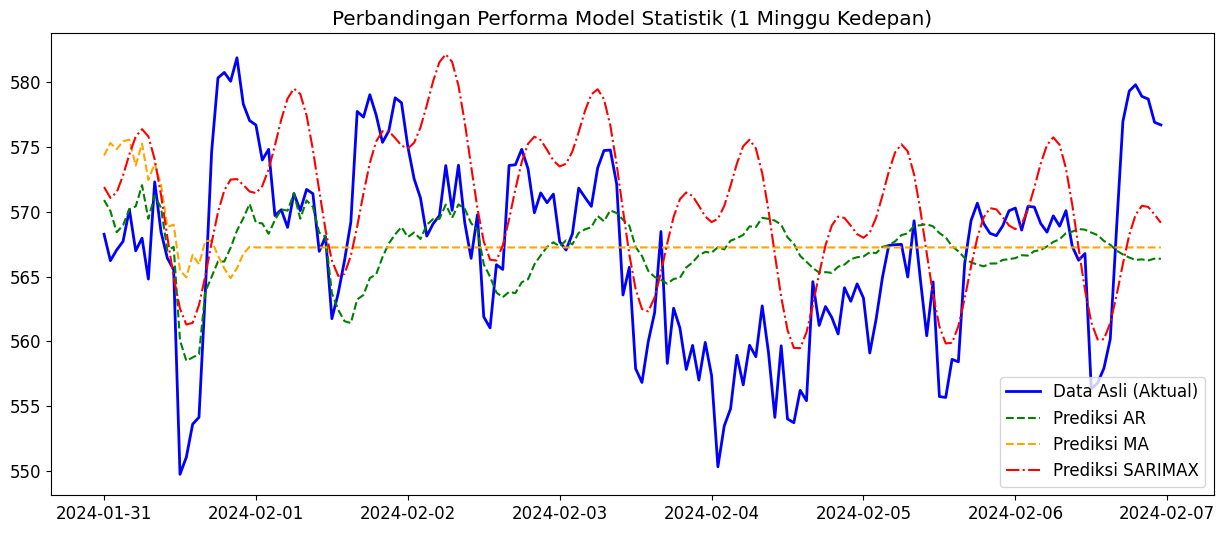

In [7]:
import warnings
from src.evaluation.metrics import ModelEvaluator
evaluator = ModelEvaluator()
from statsmodels.tsa.deterministic import Fourier
warnings.filterwarnings("ignore")


train_1d = train_data.iloc[:720]
test_1d = train_data.iloc[720:720+168]

print(f"Data Train: {len(train_1d)} baris | Data Test: {len(test_1d)} baris")

# EVALUASI AR(24)
print("\n1. Forecasting AR(24)...")
ar_res = stats_model.run_ar_model(train_1d, p=24)
ar_pred = ar_res.forecast(steps=len(test_1d))
skor_ar = evaluator.calculate_metrics(test_1d, ar_pred)
print(f"Skor AR: MAPE {skor_ar['MAPE (%)']}% | RMSE {skor_ar['RMSE']}")

# EVALUASI MA(24)
print("\n2. Forecasting MA(24)...")
ma_res = stats_model.run_ma_model(train_1d, q=24)
ma_pred = ma_res.forecast(steps=len(test_1d))
skor_ma = evaluator.calculate_metrics(test_1d, ma_pred)
print(f"Skor MA: MAPE {skor_ma['MAPE (%)']}% | RMSE {skor_ma['RMSE']}")

# EVALUASI SARIMAX + FOURIER
print("\n3. Forecasting SARIMAX + Fourier...")

sarimax_res, dp_fourier = stats_model.run_sarimax_fourier(train_1d)
exog_test = dp_fourier.out_of_sample(steps=len(test_1d))
sarimax_pred = sarimax_res.forecast(steps=len(test_1d), exog=exog_test)
skor_sarimax = evaluator.calculate_metrics(test_1d, sarimax_pred)
print(f"Skor SARIMAX: MAPE {skor_sarimax['MAPE (%)']}% | RMSE {skor_sarimax['RMSE']}")

# --- VISUALISASI KOMPARASI ---
plt.figure(figsize=(15, 6))
plt.plot(test_1d.index, test_1d.values, label='Data Asli (Aktual)', color='blue', linewidth=2)
plt.plot(test_1d.index, ar_pred, label='Prediksi AR', color='green', linestyle='--')
plt.plot(test_1d.index, ma_pred, label='Prediksi MA', color='orange', linestyle='--')
plt.plot(test_1d.index, sarimax_pred, label='Prediksi SARIMAX', color='red', linestyle='-.')
plt.title("Perbandingan Performa Model Statistik (1 Minggu Kedepan)")
plt.legend()
plt.show()

Hasil komparasi baseline statistik membuktikan adanya trade-off: Model AR/MA menghasilkan error matematis yang rendah namun gagal secara struktural (mean-reverting/flatline), sedangkan SARIMAX yang dikombinasikan dengan deret Fourier berhasil mempertahankan struktur musiman namun gagal menangkap volatilitas non-linear secara presisi (overshooting). Keterbatasan inilah yang memvalidasi urgensi penggunaan algoritma Deep Learning seperti LSTM. LSTM diharapkan tidak hanya mampu mempertahankan memori musiman jangka panjang, tetapi juga secara adaptif mempelajari volatilitas non-linear yang luput dari model klasik.

### EVALUASI AKURASI MODEL PROPHET

Data Train: 7027 baris | Data Test: 1757 baris

Training ulang Prophet dengan 80% data...


12:52:24 - cmdstanpy - INFO - Chain [1] start processing
12:52:26 - cmdstanpy - INFO - Chain [1] done processing


Forecasting...

--- SKOR PROPHET ---
RMSE: 12.398
MAE: 9.6463
MAPE (%): 1.6818
MSE: 153.7103


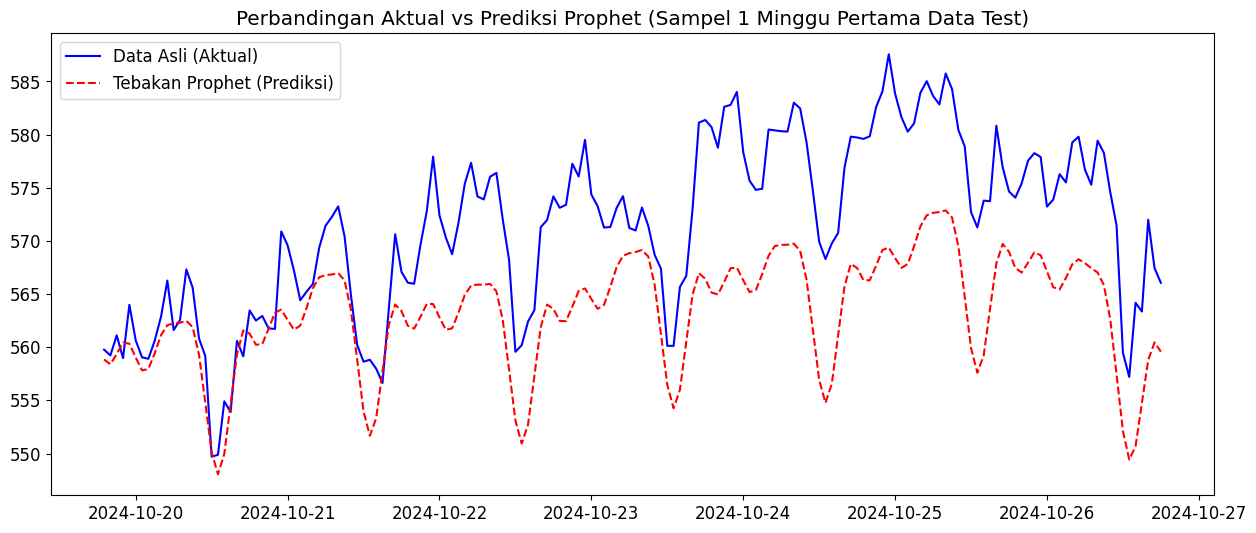

In [ ]:
from src.evaluation.metrics import ModelEvaluator


# 80% (Train), 20% (Test)
split_idx = int(len(prophet_df) * 0.8)
train_df = prophet_df.iloc[:split_idx]
test_df = prophet_df.iloc[split_idx:]

print(f"Data Train: {len(train_df)} baris | Data Test: {len(test_df)} baris")

print("\nTraining ulang Prophet dengan 80% data...")
prophet_eval = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True)
prophet_eval.fit(train_df)

print("Forecasting...")
future = prophet_eval.make_future_dataframe(periods=len(test_df), freq='h')
forecast = prophet_eval.predict(future)

predictions = forecast['yhat'].iloc[split_idx:].values
actuals = test_df['y'].values

evaluator = ModelEvaluator()
skor_prophet = evaluator.calculate_metrics(y_true=actuals, y_pred=predictions)

print("\n--- SKOR PROPHET ---")
for metric, score in skor_prophet.items():
    print(f"{metric}: {score}")

#(Aktual vs Prediksi)
plt.figure(figsize=(15, 6))
# Plot aktual vs prediksi (ambil sampel 1 minggu / 168 jam pertama di data Test)
plt.plot(test_df['ds'].iloc[:168], actuals[:168], label='Data Asli (Aktual)', color='blue')
plt.plot(test_df['ds'].iloc[:168], predictions[:168], label='Tebakan Prophet (Prediksi)', color='red', linestyle='--')
plt.title("Perbandingan Aktual vs Prediksi Prophet (Sampel 1 Minggu Pertama Data Test)")
plt.legend()
plt.show()

Berdasarkan hasil visualisasi prediksi one-week ahead, model Prophet menunjukkan keunggulan dalam menangkap frekuensi dan ritme multiple seasonality (pola harian dan mingguan) secara presisi. Namun, model statistik ini memiliki kelemahan signifikan dalam menangkap pergeseran level (level shift) dan volatilitas non-linear yang dinamis. Ketika terjadi lonjakan intensitas karbon aktual pada periode 22-26 Oktober, prediksi Prophet tetap tertahan pada baseline statisnya, menghasilkan nilai residual (error) yang besar. dari sini, kelemahan Prophet dalam menangkap dinamika non-linear dapat dikompensasi oleh arsitektur Deep Learning (LSTM) pada tahap pemodelan residual nantinya